# EDA for Personal Project

In [92]:
import os
import glob
import json
import pandas as pd
import numpy as np
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud
import warnings
from sklearn.preprocessing import MultiLabelBinarizer
warnings.filterwarnings('ignore')

## Pre processing and making the same style for all of the data and graphs

In [ ]:
data_path = 'spellsdata/**/*.json' 
parsed_spells = []

for filepath in glob.glob(data_path, recursive=True):
    if '_folders.json' in filepath: 
        continue
    try:
        with open(filepath, 'r', encoding='utf-8') as f:
            spell = json.load(f)
            if 'system' in spell:
                name = spell.get('name', 'Unknown')
                desc_html = spell['system'].get('description', {}).get('value', '')
                level = spell['system'].get('level', {}).get('value', 0)
                
                traits = spell['system'].get('traits', {}).get('value', [])
                traditions = spell['system'].get('traits', {}).get('traditions', [])
                
                all_tags = (traits if traits else []) + (traditions if traditions else [])
                folder_category = os.path.basename(os.path.dirname(filepath))
                
                parsed_spells.append({
                    'name': name,
                    'level': level,
                    'category': folder_category,
                    'description_html': desc_html,
                    'tags': all_tags
                })
    except Exception as e:
        pass

df = pd.DataFrame(parsed_spells)
print(f"Successfuly downloaded spells: {len(df)}")


def clean_html(raw_html):
    """Remove HTML tags"""
    if pd.isna(raw_html) or not raw_html:
        return ""
    return BeautifulSoup(raw_html, "html.parser").get_text(separator=" ")


df['clean_desc'] = df['description_html'].apply(clean_html)

df['word_count'] = df['clean_desc'].apply(lambda x: len(x.split()))
df['tag_count'] = df['tags'].apply(len)

print("Dataframe is ready for usage")



Successfuly downloaded spells: 1994
Dataframe is ready for usage


### Graph which shows all of the tags (AI generated)

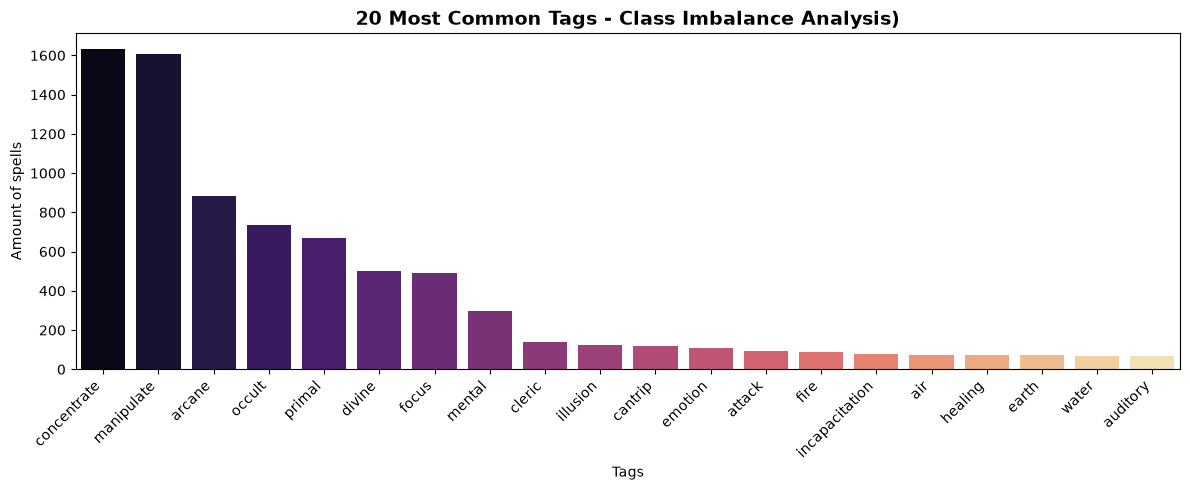

In [94]:
plt.figure(figsize=(12, 5))
all_tags_series = df.explode('tags')['tags'].dropna()
top_tags = all_tags_series.value_counts().head(20)

sns.barplot(x=top_tags.index, y=top_tags.values, palette='magma')
plt.title('20 Most Common Tags - Class Imbalance Analysis)', fontsize=14, fontweight='bold')
plt.xlabel('Tags')
plt.ylabel('Amount of spells')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Average amount of the words in one spell (AI generated)

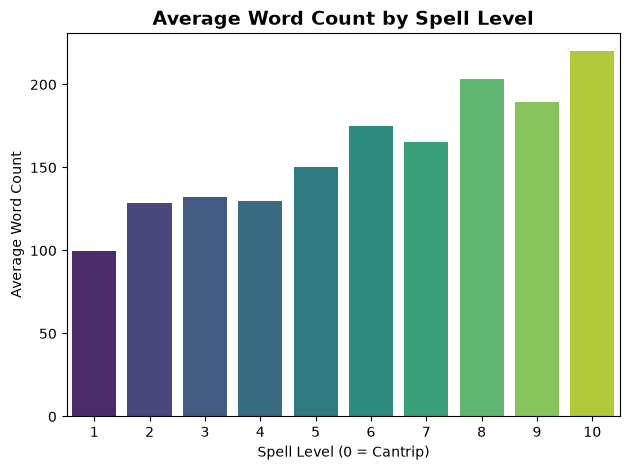

In [95]:
sns.barplot(data=df, x='level', y='word_count', estimator=np.mean, errorbar=None, palette='viridis')
plt.title('Average Word Count by Spell Level', fontsize=14, fontweight='bold')
plt.xlabel('Spell Level (0 = Cantrip)')
plt.ylabel('Average Word Count')
plt.tight_layout()
plt.show()

### Amount of the tags per spell (AI generated)

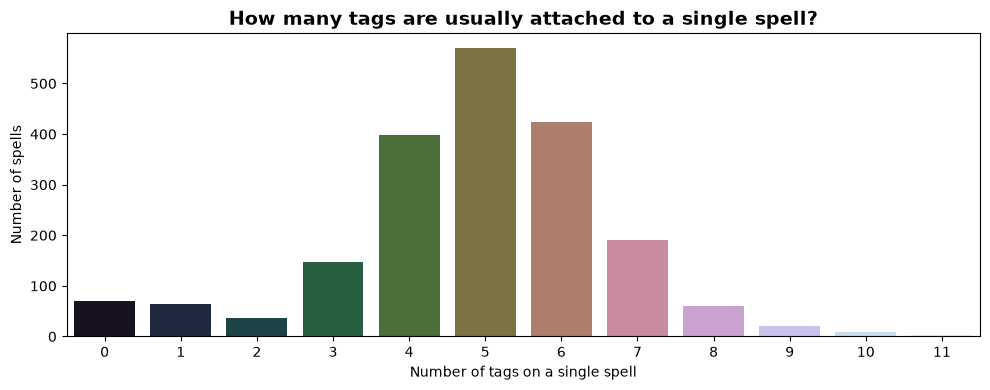

In [96]:
plt.figure(figsize=(10, 4))
sns.countplot(data=df, x='tag_count', palette='cubehelix')
plt.title('How many tags are usually attached to a single spell?', fontsize=14, fontweight='bold')
plt.xlabel('Number of tags on a single spell')
plt.ylabel('Number of spells')
plt.tight_layout()
plt.show()

### How often the same tags are in one spells

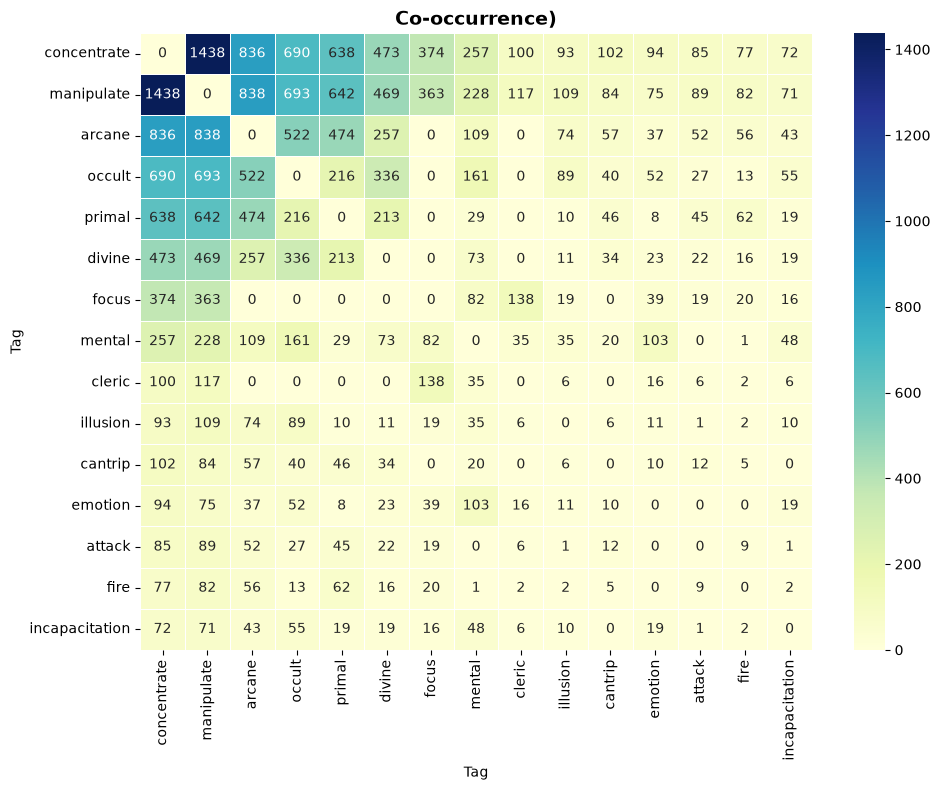

In [ ]:
#excluded_tags = {'arcane', 'occult', 'primal', 'divine'}
#filtered_tags = df['tags'].apply(
#    lambda tags: [tag for tag in (tags or []) if tag.casefold() not in excluded_tags]
#)

#mlb = MultiLabelBinarizer()
#tags_encoded = mlb.fit_transform(filtered_tags)

mlb = MultiLabelBinarizer()
tags_encoded = mlb.fit_transform(df['tags'])
tags_df = pd.DataFrame(tags_encoded, columns=mlb.classes_)

top_15_tags = tags_df.sum().nlargest(15).index
tags_top15_df = tags_df[top_15_tags]

co_matrix = tags_top15_df.T.dot(tags_top15_df)

# Remove self-co-occurrence values without modifying a read-only array
co_matrix = co_matrix.mask(
    np.eye(co_matrix.shape[0], dtype=bool),
    0
)

plt.figure(figsize=(10, 8))
sns.heatmap(co_matrix, annot=True, fmt='d', cmap='YlGnBu', linewidths=.5)
plt.title('Co-occurrence)', fontsize=14, fontweight='bold')
plt.xlabel('Tag')
plt.ylabel('Tag')
plt.tight_layout()
plt.show()

### The most common words (possible features as key words)

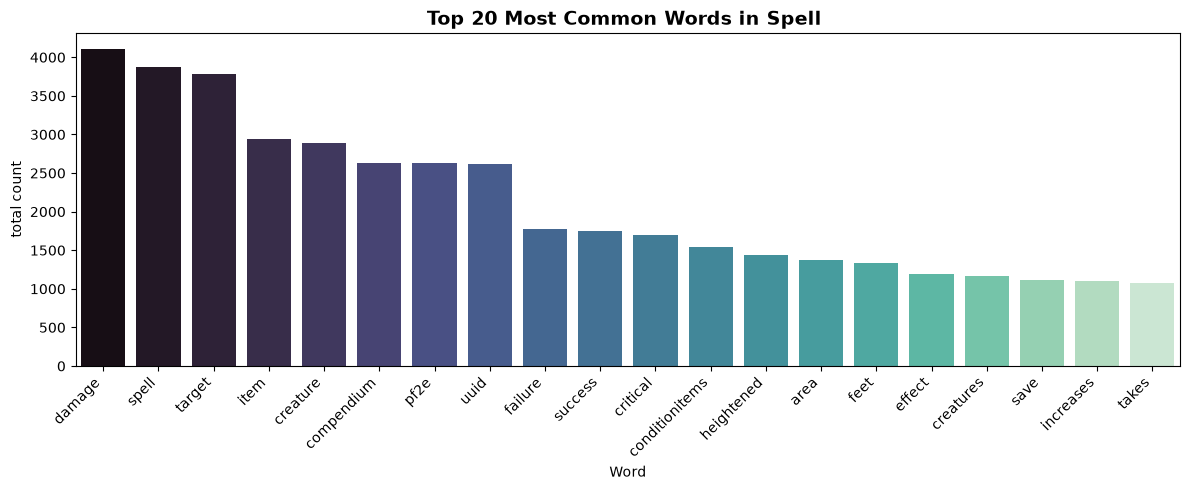

In [100]:
plt.figure(figsize=(12, 5))
# CountVectorizer deleting of the unnecessary words and limiting the number of features to 20 for better visualization
vectorizer = CountVectorizer(stop_words='english', max_features=20)
word_counts = vectorizer.fit_transform(df['clean_desc'])

# collect the words and their counts into a DataFrame for easier plotting
words_df = pd.DataFrame({
    'Word': vectorizer.get_feature_names_out(), 
    'Count': word_counts.toarray().sum(axis=0)
}).sort_values(by='Count', ascending=False)

sns.barplot(data=words_df, x='Word', y='Count', palette='mako')
plt.title('Top 20 Most Common Words in Spell ', fontsize=14, fontweight='bold')
plt.xlabel('Word')
plt.ylabel('total count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### The most common words belove 2000 count

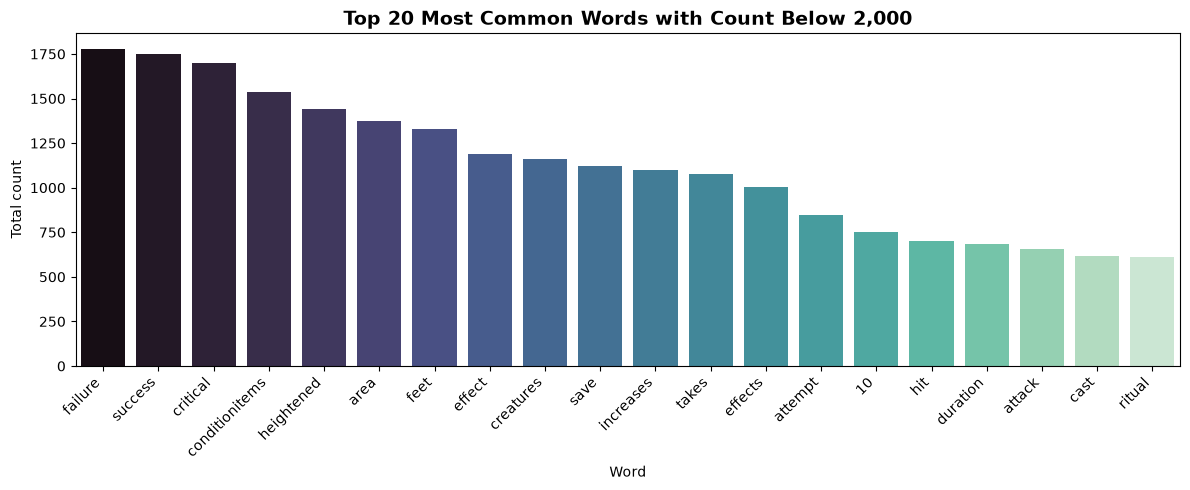

In [101]:
# Count all words, then keep only those with a total count below 2,000
filtered_vectorizer = CountVectorizer(stop_words='english')
filtered_word_counts = filtered_vectorizer.fit_transform(df['clean_desc'])

filtered_words_df = pd.DataFrame({
    'Word': filtered_vectorizer.get_feature_names_out(),
    'Count': filtered_word_counts.toarray().sum(axis=0)
})
filtered_words_df = (
    filtered_words_df[filtered_words_df['Count'] < 2000]
    .sort_values(by='Count', ascending=False)
    .head(20)
)

plt.figure(figsize=(12, 5))
sns.barplot(data=filtered_words_df, x='Word', y='Count', palette='mako')
plt.title('Top 20 Most Common Words with Count Below 2,000', fontsize=14, fontweight='bold')
plt.xlabel('Word')
plt.ylabel('Total count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()